In [14]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded!")

All libraries loaded!


In [15]:
# Cell 2 — Load and inspect data
df = pd.read_csv('../data/dataset.csv')

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

Shape: (400, 7)

Column types:
price               int64
marketing_budget    int64
competition           str
category              str
timing                str
region                str
success             int64
dtype: object

First 5 rows:
   price  marketing_budget competition     category    timing region  success
0  16295            140788        High       Health  Festival  Urban        1
1   1360            220963         Low         Food    Normal  Rural        1
2  38658            481761         Low  Electronics    Normal  Urban        1
3  45232            249710      Medium     Clothing  Festival  Rural        1
4  11784            221984      Medium  Electronics  Festival  Rural        1

Basic statistics:
              price  marketing_budget     success
count    400.000000        400.000000  400.000000
mean   24640.915000     234414.812500    0.607500
std    15055.319494     144184.936671    0.488919
min      661.000000       2542.000000    0.000000
25%    11169.500000  

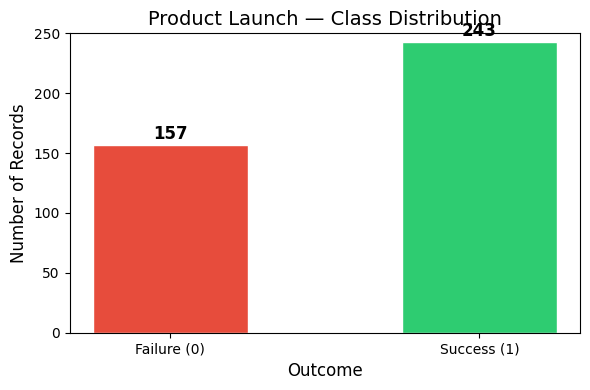

Chart saved to plots/class_distribution.png


In [16]:
# Cell 3 — Class distribution chart
plt.figure(figsize=(6, 4))

counts = df['success'].value_counts()
colors = ['#e74c3c', '#2ecc71']

plt.bar(['Failure (0)', 'Success (1)'],
        [counts[0], counts[1]],
        color=colors, width=0.5, edgecolor='white')

plt.title('Product Launch — Class Distribution', fontsize=14)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.ylim(0, 250)

# Add count labels on top of each bar
for i, val in enumerate([counts[0], counts[1]]):
    plt.text(i, val + 5, str(val),
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=150)
plt.show()

print("Chart saved to plots/class_distribution.png")

In [17]:
# Cell 4 — Temporary numeric conversion for heatmap
df_numeric = df.copy()

df_numeric['competition'] = df_numeric['competition'].map(
    {'Low': 2, 'Medium': 1, 'High': 0}
)
df_numeric['category'] = df_numeric['category'].map(
    {'Electronics': 0, 'Clothing': 1, 'Food': 2, 'Health': 3}
)
df_numeric['timing'] = df_numeric['timing'].map(
    {'Festival': 1, 'Normal': 0}
)
df_numeric['region'] = df_numeric['region'].map(
    {'Urban': 1, 'Rural': 0}
)

print("Numeric copy created")
print(df_numeric.head())

Numeric copy created
   price  marketing_budget  competition  category  timing  region  success
0  16295            140788            0         3       1       1        1
1   1360            220963            2         2       0       0        1
2  38658            481761            2         0       0       1        1
3  45232            249710            1         1       1       0        1
4  11784            221984            1         0       1       0        1


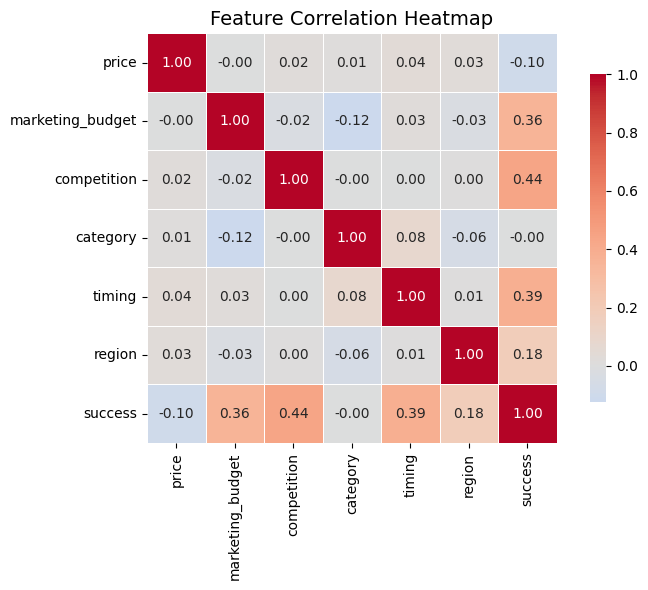

Heatmap saved to plots/correlation_heatmap.png


In [18]:
# Cell 5 — Correlation heatmap
plt.figure(figsize=(8, 6))

corr_matrix = df_numeric.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=150)
plt.show()

print("Heatmap saved to plots/correlation_heatmap.png")

In [19]:
# Cell 6 — Label encoding
df_encoded = df.copy()

# Encode competition — Low is best so give it highest number
df_encoded['competition'] = df_encoded['competition'].map(
    {'Low': 2, 'Medium': 1, 'High': 0}
)

# Encode category
df_encoded['category'] = df_encoded['category'].map(
    {'Electronics': 0, 'Clothing': 1, 'Food': 2, 'Health': 3}
)

# Encode timing
df_encoded['timing'] = df_encoded['timing'].map(
    {'Festival': 1, 'Normal': 0}
)

# Encode region
df_encoded['region'] = df_encoded['region'].map(
    {'Urban': 1, 'Rural': 0}
)

print("Encoding done!")
print("\nEncoded dataframe:")
print(df_encoded.head(10))
print("\nData types after encoding:")
print(df_encoded.dtypes)


Encoding done!

Encoded dataframe:
   price  marketing_budget  competition  category  timing  region  success
0  16295            140788            0         3       1       1        1
1   1360            220963            2         2       0       0        1
2  38658            481761            2         0       0       1        1
3  45232            249710            1         1       1       0        1
4  11784            221984            1         0       1       0        1
5   6765            373771            0         2       1       0        1
6  17350            333460            0         2       0       0        0
7  37694            259067            2         2       0       1        1
8  22462            265512            0         0       0       1        0
9  47691             78575            1         0       1       1        0

Data types after encoding:
price               int64
marketing_budget    int64
competition         int64
category            int64
timing  

In [20]:
# Cell 7 — Check for nulls after encoding
print("Null values after encoding:")
print(df_encoded.isnull().sum())

print("\nUnique values per column:")
for col in df_encoded.columns:
    print(f"{col}: {sorted(df_encoded[col].unique())}")

Null values after encoding:
price               0
marketing_budget    0
competition         0
category            0
timing              0
region              0
success             0
dtype: int64

Unique values per column:
price: [np.int64(661), np.int64(689), np.int64(690), np.int64(697), np.int64(706), np.int64(801), np.int64(1069), np.int64(1163), np.int64(1199), np.int64(1269), np.int64(1284), np.int64(1354), np.int64(1360), np.int64(1516), np.int64(1521), np.int64(1654), np.int64(1767), np.int64(1806), np.int64(2085), np.int64(2136), np.int64(2178), np.int64(2185), np.int64(2234), np.int64(2302), np.int64(2399), np.int64(2527), np.int64(2549), np.int64(2700), np.int64(2827), np.int64(2933), np.int64(3057), np.int64(3068), np.int64(3112), np.int64(3193), np.int64(3195), np.int64(3247), np.int64(3311), np.int64(3369), np.int64(3411), np.int64(3461), np.int64(3804), np.int64(3920), np.int64(3936), np.int64(4056), np.int64(4061), np.int64(4127), np.int64(4248), np.int64(4390), np.int64

In [21]:
# Cell 8 — Separate X and y
X = df_encoded.drop('success', axis=1)
y = df_encoded['success']

print("Feature matrix X:")
print(f"  Shape: {X.shape}")
print(f"  Columns: {list(X.columns)}")

print("\nTarget vector y:")
print(f"  Shape: {y.shape}")
print(f"  Unique values: {sorted(y.unique())}")
print(f"  Value counts:\n{y.value_counts()}")

Feature matrix X:
  Shape: (400, 6)
  Columns: ['price', 'marketing_budget', 'competition', 'category', 'timing', 'region']

Target vector y:
  Shape: (400,)
  Unique values: [np.int64(0), np.int64(1)]
  Value counts:
success
1    243
0    157
Name: count, dtype: int64


In [22]:
# Cell 9 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split complete!")
print(f"\nTraining set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

print(f"\nTraining class balance:")
print(y_train.value_counts())

print(f"\nTest class balance:")
print(y_test.value_counts())


Split complete!

Training set:  320 rows
Test set:      80 rows

Training class balance:
success
1    194
0    126
Name: count, dtype: int64

Test class balance:
success
1    49
0    31
Name: count, dtype: int64


In [23]:
# Cell 10 — Day 2 summary
print("=" * 40)
print("DAY 2 SUMMARY")
print("=" * 40)

print(f"\nOriginal dataset:     {df.shape}")
print(f"Encoded dataset:      {df_encoded.shape}")
print(f"Any nulls remaining:  {df_encoded.isnull().sum().sum()}")

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print(f"\nFeature columns used for training:")
for col in X_train.columns:
    print(f"  - {col}")

print(f"\nAll columns are numeric: "
      f"{all(X_train.dtypes != 'object')}")

DAY 2 SUMMARY

Original dataset:     (400, 7)
Encoded dataset:      (400, 7)
Any nulls remaining:  0

X_train shape: (320, 6)
X_test shape:  (80, 6)
y_train shape: (320,)
y_test shape:  (80,)

Feature columns used for training:
  - price
  - marketing_budget
  - competition
  - category
  - timing
  - region

All columns are numeric: True


In [24]:
# Cell 11 — Confirm plots saved
import os

plots = [
    '../plots/class_distribution.png',
    '../plots/correlation_heatmap.png'
]

for p in plots:
    if os.path.exists(p):
        size = os.path.getsize(p)
        print(f"EXISTS: {p}  ({size:,} bytes)")
    else:
        print(f"MISSING: {p}  — re-run the chart cell!")

EXISTS: ../plots/class_distribution.png  (28,634 bytes)
EXISTS: ../plots/correlation_heatmap.png  (95,390 bytes)
